# 03 · Yeast-display benchmark — Birnbaum (Rmd 4)

Reproduces `code_paper/4_Benchmark_yeast_display.Rmd` on the **2026 TCRen**. Three mouse
TCRs with solved structures — **2b4/`3qib`, 226/`3qiu`, 5cc7/`4p2r`** — were profiled by
yeast display (Birnbaum et al. 2014): each selected a library of 13-mer peptides ranked by
round-5 enrichment.

For each TCR we ask whether TCRen, threading peptides onto that structure's TCR–peptide
contact map, separates the **top-50 yeast-enriched binders** from random decoy peptides
(ROC AUC), and whether the TCRen energy of a real peptide tracks its yeast enrichment.

To avoid train/test leakage the potential is **leave-cluster-out**: derived from the
non-redundant 2026 set with every structure in the same sequence cluster as a test PDB
removed (mirrors the Rmd's `calc_TCRen(exclude = exclude.birnbaum.pdb)`).

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, polars as pl
from tcren.potential import derive_tcren

R = 'results_new'
AA = list('LFIMVWYCHAGPTSQNDERK'); AIDX = {a: i for i, a in enumerate(AA)}
TCR2PDB = {'2b4': '3qib', '226': '3qiu', '5cc7': '4p2r'}

contacts = pl.read_csv(f'{R}/contacts_2026.csv')
markup = pl.read_csv(f'{R}/markup_2026.csv')
loo = pl.read_csv(f'{R}/TCRen_2026_LOO.csv')
nonred = sorted(loo['pdb.id'].unique().to_list())            # 2026 non-redundant representatives
ab = contacts.filter(pl.col('chain.type.from').is_in(['TRA', 'TRB']))

birnbaum = pl.read_csv('data_legacy/Birnbaum.tsv.gz', separator='\t')
print('Birnbaum peptides per TCR:', birnbaum.group_by('TCR').len().sort('TCR').to_dicts())
print('test PDBs in non-redundant set:', {p: (p in nonred) for p in TCR2PDB.values()})

Birnbaum peptides per TCR: [{'TCR': '226', 'len': 736}, {'TCR': '2b4', 'len': 130}, {'TCR': '5cc7', 'len': 406}]
test PDBs in non-redundant set: {'3qib': True, '3qiu': True, '4p2r': True}


In [2]:
# Leave-cluster-out: drop every non-redundant structure sharing a sequence cluster with a test
# PDB, then derive TCRen from the rest. Clustering matches notebook 01 (summed Damerau-Levenshtein
# of cdr3a+cdr3b+peptide, complete linkage, cut at h=6) over the alpha-beta set.
from rapidfuzz.distance import DamerauLevenshtein
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform

ab_ids = [r['pdb.id'] for r in contacts.group_by('pdb.id').agg(
    pl.col('chain.type.from').unique().alias('x')).iter_rows(named=True)
    if set(r['x']) <= {'TRA', 'TRB'}]
mk = markup.filter(pl.col('pdb.id').is_in(ab_ids)).with_columns(
    [pl.col(c).fill_null('') for c in ['cdr3a', 'cdr3b', 'peptide']])
ids = mk['pdb.id'].to_list(); seqs = {c: mk[c].to_list() for c in ['cdr3a', 'cdr3b', 'peptide']}
n = len(ids); D = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        d = sum(DamerauLevenshtein.distance(seqs[c][i], seqs[c][j]) for c in seqs)
        D[i, j] = D[j, i] = d
cl = fcluster(linkage(squareform(D), method='complete'), t=6, criterion='distance')
cluster_of = dict(zip(ids, cl))

excluded_clusters = {cluster_of[p] for p in TCR2PDB.values()}
exclude = {p for p, c in cluster_of.items() if c in excluded_clusters}
include_lco = [p for p in nonred if cluster_of.get(p) not in excluded_clusters]
print(f'excluded {len(exclude)} structures in {len(excluded_clusters)} Birnbaum clusters: {sorted(exclude)}')
print(f'leave-cluster-out TCRen derived from {len(include_lco)} / {len(nonred)} non-redundant structures')

def mat_from(df, vcol='value'):
    m = np.zeros((20, 20))
    for r in df.iter_rows(named=True):
        i, j = AIDX.get(r['residue.aa.from']), AIDX.get(r['residue.aa.to'])
        if i is not None and j is not None:
            m[i, j] = r[vcol]
    return m

M_lco = mat_from(derive_tcren(contacts, include=include_lco).matrix)
M_full = mat_from(pl.read_csv(f'{R}/TCRen_2026.csv'))

excluded 4 structures in 3 Birnbaum clusters: ['3qib', '3qiu', '3qiw', '4p2r']
leave-cluster-out TCRen derived from 216 / 219 non-redundant structures


In [3]:
# Score peptides by threading onto a structure's TCR-peptide contacts (sum of the potential).
def contacts_for(pid):
    sub = ab.filter(pl.col('pdb.id') == pid)
    pos = np.array(sub['pos.to'].to_list())
    tcr = np.array([AIDX.get(a, -1) for a in sub['residue.aa.from'].to_list()])
    keep = (pos >= 0) & (tcr >= 0)
    return pos[keep], tcr[keep]

def energies(pid, idx, M):
    pos, tcr = contacts_for(pid)
    keep = pos < idx.shape[1]; pos, tcr = pos[keep], tcr[keep]
    return M[tcr[None, :], idx[:, pos]].sum(axis=1)              # (N,) lower = better binder

def to_idx(peps):
    return np.array([[AIDX[a] for a in p] for p in peps])

N_DECOY = 1000
rng = np.random.default_rng(0)
# Top-50 yeast binders per TCR (real positives); valid 20-aa peptides only.
real_peptides = {}
for tcr in TCR2PDB:
    peps = (birnbaum.filter(pl.col('TCR') == tcr).sort('round_5', descending=True)['peptide']
            .to_list())
    real_peptides[tcr] = [p for p in peps if all(a in AIDX for a in p)][:50]
print('real (top-50) per TCR:', {t: len(v) for t, v in real_peptides.items()})

real (top-50) per TCR: {'2b4': 50, '226': 50, '5cc7': 50}


In [4]:
# Fig 4 (ROC): does TCRen separate top-50 yeast binders from random decoys? AUC per TCR.
from sklearn.metrics import roc_auc_score, roc_curve

roc_data = {}; rows = []
for tcr, pid in TCR2PDB.items():
    real = to_idx(real_peptides[tcr]); L = real.shape[1]
    cog = real[0]
    dec = rng.integers(0, 20, size=(N_DECOY, L)); dec[:, 1] = cog[1]; dec[:, L - 1] = cog[L - 1]
    idx = np.vstack([real, dec]); y = np.r_[np.ones(len(real)), np.zeros(N_DECOY)]
    for name, M in [('TCRen (LCO)', M_lco), ('TCRen 2026 (full)', M_full)]:
        score = -energies(pid, idx, M)                          # higher score = better binder
        auc = roc_auc_score(y, score)
        rows.append({'TCR': tcr, 'pdb.id': pid, 'potential': name, 'AUC': round(auc, 2)})
        if name == 'TCRen (LCO)':
            roc_data[tcr] = (roc_curve(y, score), auc)
auc_birnbaum = pl.DataFrame(rows)
auc_birnbaum.write_csv(f'{R}/benchmark_birnbaum.csv')
auc_birnbaum

TCR,pdb.id,potential,AUC
str,str,str,f64
"""2b4""","""3qib""","""TCRen (LCO)""",0.95
"""2b4""","""3qib""","""TCRen 2026 (full)""",0.96
"""226""","""3qiu""","""TCRen (LCO)""",0.87
"""226""","""3qiu""","""TCRen 2026 (full)""",0.95
"""5cc7""","""4p2r""","""TCRen (LCO)""",0.66
"""5cc7""","""4p2r""","""TCRen 2026 (full)""",0.75


In [5]:
# Enrichment correlation: does the TCRen binding score track yeast-display affinity?
# Affinity proxy = log fold-enrichment between the last selection rounds,
# log((round_5+1)/(round_3+1)); denoise by requiring >=10 reads in round_3 (the ratio
# baseline) so low-count peptides don't dominate. Binding score = -energy (the contact
# potential threaded onto the structure; lower energy = stronger binder), so a positive
# Spearman rho means TCRen tracks affinity. (Earlier we ranked only the top-50 by round_5
# vs % decoys beaten, which carried almost no signal; the log-ratio + denoise is far better.)
from scipy.stats import spearmanr

MIN_ROUND3 = 10
corr_rows = []; scatter = {}
for tcr, pid in TCR2PDB.items():
    sel = (birnbaum.filter(pl.col('TCR') == tcr)
           .filter(pl.col('peptide').map_elements(lambda p: all(a in AIDX for a in p), return_dtype=bool))
           .filter(pl.col('round_3') >= MIN_ROUND3)
           .with_columns(((pl.col('round_5') + 1) / (pl.col('round_3') + 1)).log().alias('log_enrich')))
    peps = sel['peptide'].to_list()
    enrich = np.array(sel['log_enrich'].to_list())            # higher = stronger binder
    score = -energies(pid, to_idx(peps), M_lco)               # higher = stronger binder (lower energy)
    rho, p = spearmanr(enrich, score)
    corr_rows.append({'TCR': tcr, 'pdb.id': pid, 'n': len(peps),
                      'spearman_rho': round(float(rho), 2), 'p': float(f'{p:.1e}')})
    scatter[tcr] = (enrich, score)
pl.DataFrame(corr_rows)

TCR,pdb.id,n,spearman_rho,p
str,str,i64,f64,f64
"""2b4""","""3qib""",21,0.43,0.05
"""226""","""3qiu""",323,0.02,0.68
"""5cc7""","""4p2r""",116,0.25,0.0073


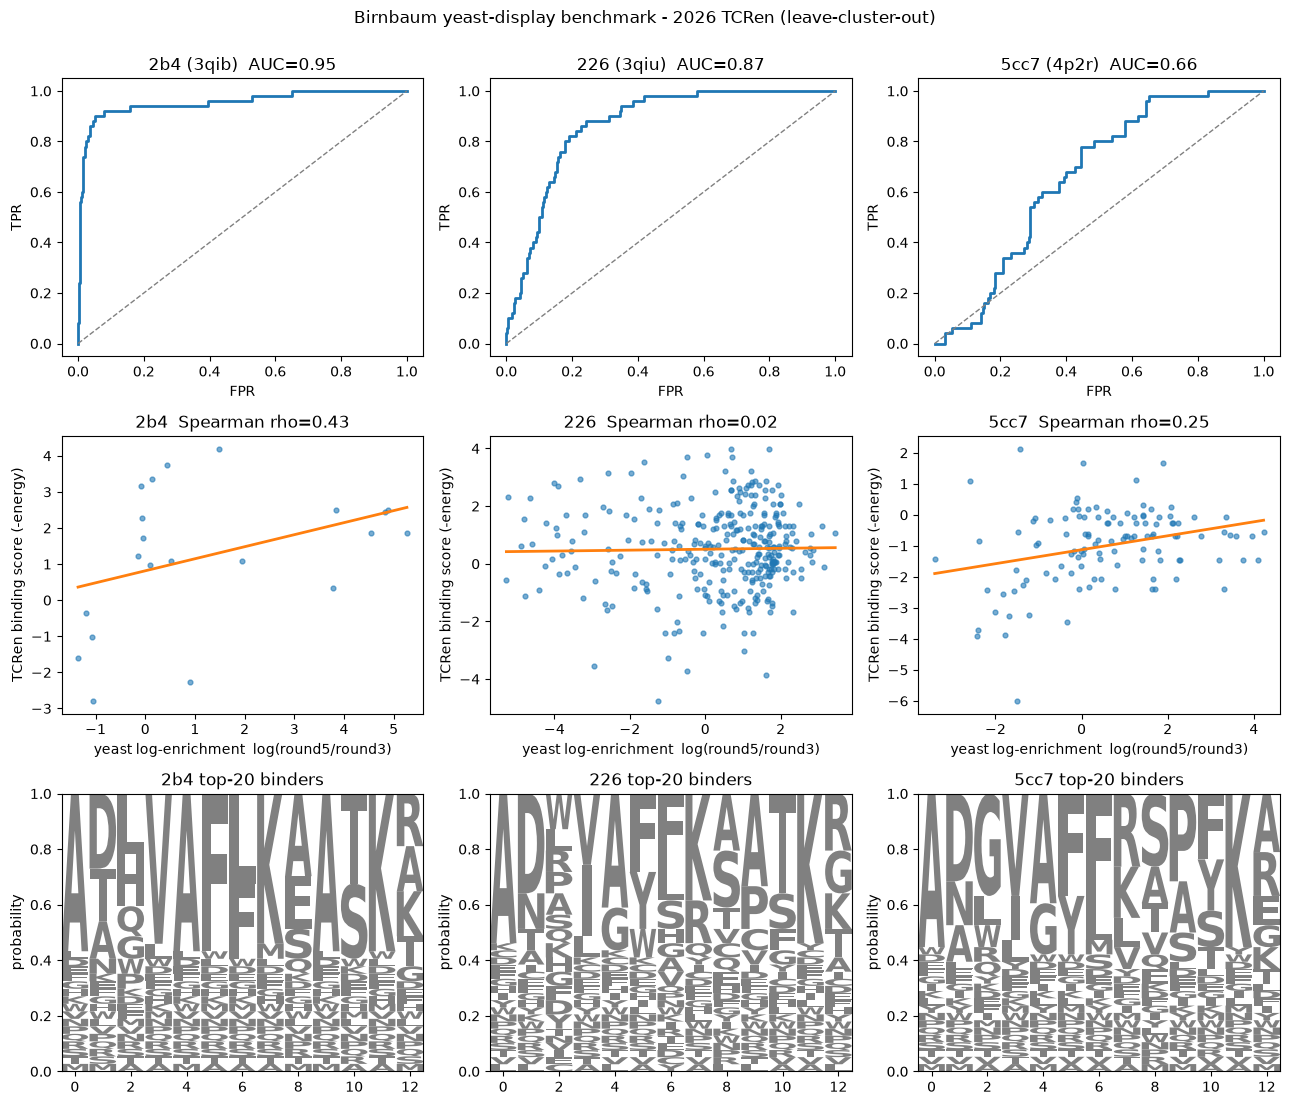

In [6]:
# Figure: ROC curves, affinity-enrichment scatter, and top-20 binder sequence logos per TCR.
%matplotlib inline
import matplotlib.pyplot as plt
import logomaker

fig, axes = plt.subplots(3, 3, figsize=(13, 11))
for col, (tcr, pid) in enumerate(TCR2PDB.items()):
    (fpr, tpr, _), auc = roc_data[tcr]
    ax = axes[0, col]
    ax.plot(fpr, tpr, lw=2); ax.plot([0, 1], [0, 1], ls='--', c='grey', lw=1)
    ax.set_title(f'{tcr} ({pid})  AUC={auc:.2f}'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')

    enrich, score = scatter[tcr]; ax = axes[1, col]
    ax.scatter(enrich, score, s=12, alpha=0.6)
    b, a = np.polyfit(enrich, score, 1); xs = np.array([enrich.min(), enrich.max()])
    ax.plot(xs, a + b * xs, c='C1', lw=2)
    rho = next(r['spearman_rho'] for r in corr_rows if r['TCR'] == tcr)
    ax.set_title(f'{tcr}  Spearman rho={rho}')
    ax.set_xlabel('yeast log-enrichment  log(round5/round3)'); ax.set_ylabel('TCRen binding score (-energy)')

    top20 = [p for p in birnbaum.filter(pl.col('TCR') == tcr).sort('round_5', descending=True)['peptide'].to_list()
             if all(a in AIDX for a in p)][:20]
    cm = logomaker.alignment_to_matrix(top20, to_type='probability')
    ax = axes[2, col]
    logomaker.Logo(cm, ax=ax)
    ax.set_title(f'{tcr} top-20 binders'); ax.set_ylabel('probability')
fig.suptitle('Birnbaum yeast-display benchmark - 2026 TCRen (leave-cluster-out)', y=1.0)
plt.tight_layout()